## **Exploratory Data Analysis & Data Preparation**

#### 
- Load and explore the resume dataset
- Perform comprehensive EDA
- Assess data quality
- Clean and prepare data for modeling

In [107]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [108]:
# Load dataset
df = pd.read_csv('dataset/resumeJD_pairs.csv', engine='python', on_bad_lines='skip')
print(f"Data Loaded Successfully: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")

Data Loaded Successfully: 320 rows, 4 columns

Columns: ['resume_text', 'job_description', 'match_score', 'match_label']


In [109]:
print("First 5 rows:")
df.head()

First 5 rows:


,resume_text,job_description,match_score,match_label
0,Python developer with 8 years of experience bu...,We need a Frontend Developer experienced with ...,0.44,Medium
1,UI/UX Designer with 3 years of experience in w...,Seeking a Business Analyst with experience in ...,0.41,medium
2,Business Analyst with 9 years of experience in...,Seeking a Business Analyst with experience in ...,0.95,HIGH
3,Backend Developer with 9 years of experience b...,Hiring a Java Developer with experience in SQL...,0.66,Medium
4,Machine Learning Engineer with 3 years of expe...,"Seeking a Cloud Engineer experienced in Linux,...",0.34,LOW


In [110]:
# information
print("Dataset Info:")
print("=" * 60)
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resume_text      318 non-null    object 
 1   job_description  319 non-null    object 
 2   match_score      320 non-null    float64
 3   match_label      319 non-null    object 
dtypes: float64(1), object(3)
memory usage: 10.1+ KB


In [111]:
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,match_score
count,320.000000
mean,0.851500
std,5.511281
min,-0.150000
25%,0.290000
50%,0.550000
75%,0.830000
max,99.000000


In [112]:
print("\nText Columns Summary:")
df.describe(include='object')


Text Columns Summary:


,resume_text,job_description,match_label
count,318,319,319
unique,306,306,9
top,Java Developer with 4 years of experience deve...,Seeking a Business Analyst with experience in ...,HIGH
freq,2,2,42


In [113]:
# Check for missing values
print("Missing Values Analysis:")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
})
print(missing_df)
print(f"\nTotal missing values: {missing.sum()}")

Missing Values Analysis:
                 Missing_Count  Percentage
resume_text                  2      0.6250
job_description              1      0.3125
match_score                  0      0.0000
match_label                  1      0.3125

Total missing values: 4


In [114]:
# Show the rows with nulls
nulls = df[df.isnull().any(axis=1)]
print(f"Rows with at least one null: {len(nulls)}")
print(nulls[['match_label', 'match_score']])

Rows with at least one null: 4
    match_label  match_score
158        High         0.88
246         NaN         0.91
273      medium         0.52
279        high         0.87


In [115]:
full_dupes = df.duplicated().sum()
print(f"Full duplicate rows: {full_dupes}")

Full duplicate rows: 7


In [116]:
pair_dupes = df.duplicated(subset=['resume_text', 'job_description']).sum()
print(f"Duplicate resume+JD pairs: {pair_dupes}")

Duplicate resume+JD pairs: 12


In [117]:
print("\nDuplicate rows:")
df[df.duplicated(subset=['resume_text', 'job_description'], keep=False)]


Duplicate rows:


,resume_text,job_description,match_score,match_label
7,Frontend Developer with 2 years of experience ...,We need a Frontend Developer experienced with ...,0.78,High
11,Business Analyst with 6 years of experience in...,Seeking a Business Analyst with experience in ...,0.87,High
13,Data Scientist with 8 years of experience usin...,"Looking for a Data Scientist skilled in NumPy,...",0.87,HIGH
26,Cybersecurity Analyst with 9 years of experien...,Looking for a Cybersecurity Analyst with knowl...,0.33,HIGH
45,UI/UX Designer with 2 years of experience in F...,Hiring a UI/UX Designer skilled in responsive ...,0.88,high
53,Cybersecurity Analyst with 5 years of experien...,Looking for a Cybersecurity Analyst with knowl...,0.87,high
57,Backend Developer with 2 years of experience b...,Looking for a Backend Developer experienced in...,0.76,high
96,Java Developer with 4 years of experience deve...,Hiring a Java Developer with experience in Doc...,0.56,High
142,Frontend Developer with 5 years of experience ...,We need a Frontend Developer experienced with ...,0.86,HIGH
145,Cybersecurity Analyst with 9 years of experien...,Looking for a Cybersecurity Analyst with knowl...,0.94,HIGH


In [118]:
#Uniqueness Checks 

print(f"Total rows:          {len(df)}")
print(f"Unique resumes:      {df['resume_text'].nunique()}")
print(f"Unique JDs:          {df['job_description'].nunique()}")
print(f"Unique resume+JD pairs: {df[['resume_text','job_description']].drop_duplicates().shape[0]}")


Total rows:          320
Unique resumes:      306
Unique JDs:          306
Unique resume+JD pairs: 308


In [119]:
# ─── Section: Label Consistency ───────────────────────────────────────────────

# What labels exist? (spot the case inconsistency!)
print("Unique labels found:")
print(df['match_label'].value_counts())

# Is the casing consistent?
print(f"\nExpected 3 labels, got: {df['match_label'].nunique()} unique values")
print("Distinct values:", df['match_label'].unique())


Unique labels found:
match_label
HIGH      42
Medium    39
high      38
low       37
medium    36
High      36
LOW       35
Low       29
MEDIUM    27
Name: count, dtype: int64

Expected 3 labels, got: 9 unique values
Distinct values: ['Medium' 'medium' 'HIGH' 'LOW' 'High' 'Low' 'low' 'high' 'MEDIUM' nan]


In [120]:
print("Score distribution:")
print(df['match_score'].describe())
print()

# Scores must be between 0.0 and 1.0 — flag the bad ones
invalid_scores = df[(df['match_score'] < 0) | (df['match_score'] > 1)]
print(f"Invalid scores (out of 0–1 range): {len(invalid_scores)}")
print(invalid_scores[['match_label', 'match_score']])


Score distribution:
count    320.000000
mean       0.851500
std        5.511281
min       -0.150000
25%        0.290000
50%        0.550000
75%        0.830000
max       99.000000
Name: match_score, dtype: float64

Invalid scores (out of 0–1 range): 3
    match_label  match_score
6          High        99.00
46         HIGH         1.25
218         low        -0.15


In [121]:
# Label vs Score  Check


print("Score stats per label (after lowercasing):")
df['match_label_lower'] = df['match_label'].str.lower()
print(df.groupby('match_label_lower')['match_score'].describe().round(2))


#   high   → 0.75 – 0.95
#   medium → 0.40 – 0.70
#   low    → 0.05 – 0.35


Score stats per label (after lowercasing):
                   count  mean   std   min   25%   50%   75%    max
match_label_lower                                                  
high               116.0  1.69  9.11  0.32  0.80  0.86  0.90  99.00
low                101.0  0.19  0.09 -0.15  0.12  0.20  0.27   0.35
medium             102.0  0.54  0.09  0.41  0.48  0.54  0.62   0.70


In [122]:
# Null Values

print("Missing values per column:")
print(df.isnull().sum())
print()

# Show the rows with nulls
nulls = df[df.isnull().any(axis=1)]
print(f"Rows with at least one null: {len(nulls)}")
nulls[['match_label', 'match_score']].head(10)


Missing values per column:
resume_text          2
job_description      1
match_score          0
match_label          1
match_label_lower    1
dtype: int64

Rows with at least one null: 4


,match_label,match_score
158,High,0.88
246,NaN,0.91
273,medium,0.52
279,high,0.87


In [123]:
#All issues found

print("=" * 50)
print("DATA QUALITY REPORT — merged_dataset.csv")
print("=" * 50)
print(f"  Total rows:             {len(df)}")
print(f"  Full duplicates:        {df.duplicated().sum()}")
print(f"  Duplicate pairs:        {df.duplicated(subset=['resume_text','job_description']).sum()}")
print(f"  Null resume_text:       {df['resume_text'].isnull().sum()}")
print(f"  Null job_description:   {df['job_description'].isnull().sum()}")
print(f"  Label case variants:    {df['match_label'].nunique()} (expected 3)")
print(f"  Invalid scores (<0/>1): {((df['match_score'] < 0) | (df['match_score'] > 1)).sum()}")
print("=" * 50)

DATA QUALITY REPORT — merged_dataset.csv
  Total rows:             320
  Full duplicates:        7
  Duplicate pairs:        12
  Null resume_text:       2
  Null job_description:   1
  Label case variants:    9 (expected 3)
  Invalid scores (<0/>1): 3


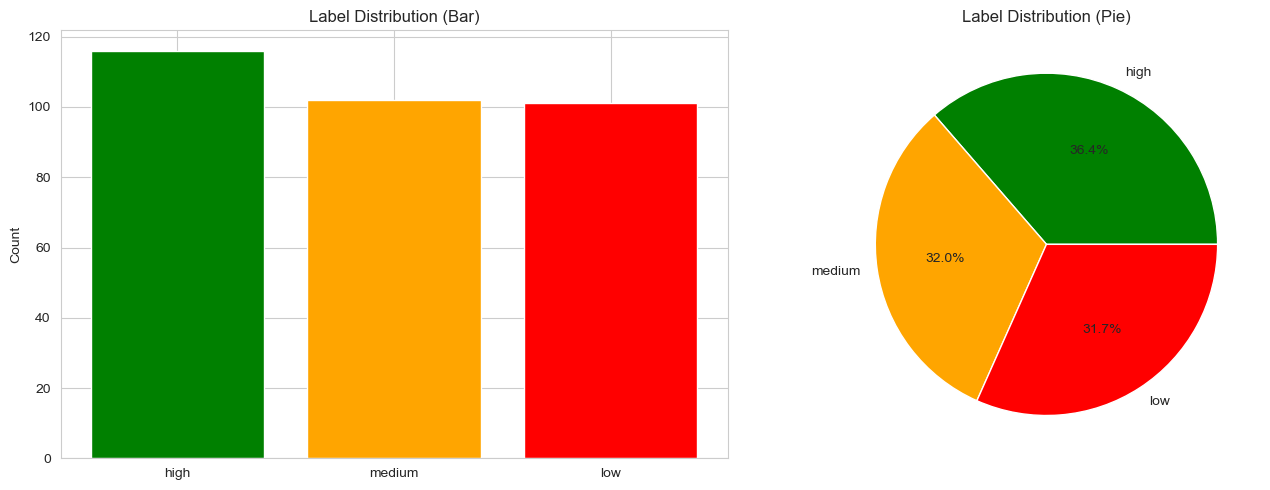

In [124]:
# Pie chart + bar side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['match_label'].str.lower().value_counts()

axes[0].bar(counts.index, counts.values, color=['green','orange','red'])
axes[0].set_title('Label Distribution (Bar)')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['green','orange','red'])
axes[1].set_title('Label Distribution (Pie)')

plt.tight_layout()
plt.show()


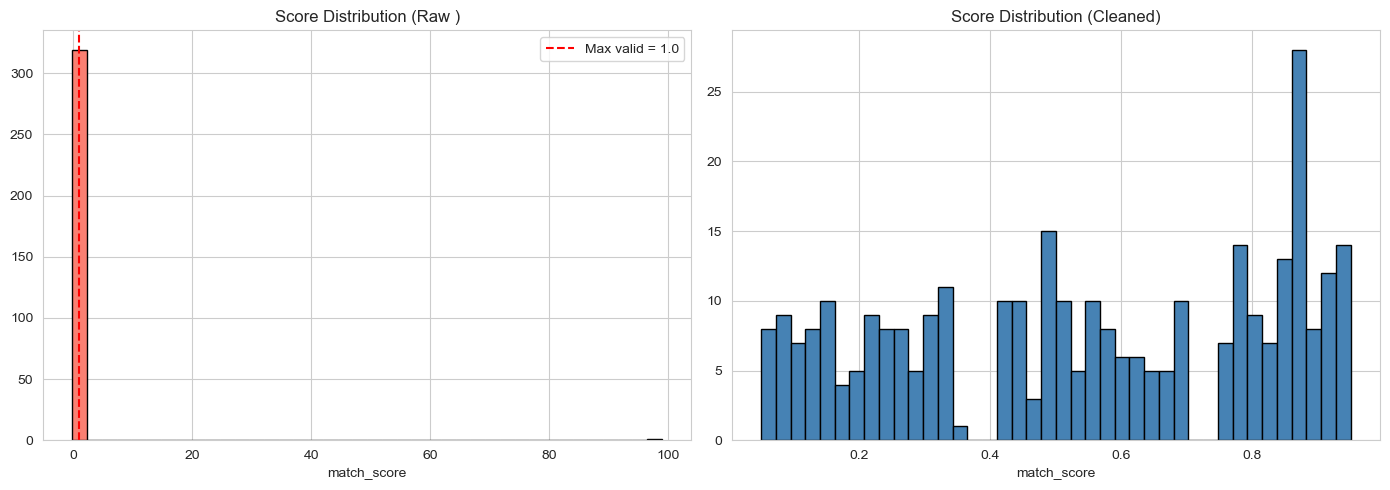

In [125]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before cleaning
axes[0].hist(df['match_score'], bins=40, color='salmon', edgecolor='black')
axes[0].set_title('Score Distribution (Raw )')
axes[0].set_xlabel('match_score')
axes[0].axvline(1.0, color='red', linestyle='--', label='Max valid = 1.0')
axes[0].legend()

# After cleaning
clean = df[(df['match_score'] >= 0) & (df['match_score'] <= 1)]
axes[1].hist(clean['match_score'], bins=40, color='steelblue', edgecolor='black')
axes[1].set_title('Score Distribution (Cleaned)')
axes[1].set_xlabel('match_score')

plt.tight_layout()
plt.show()

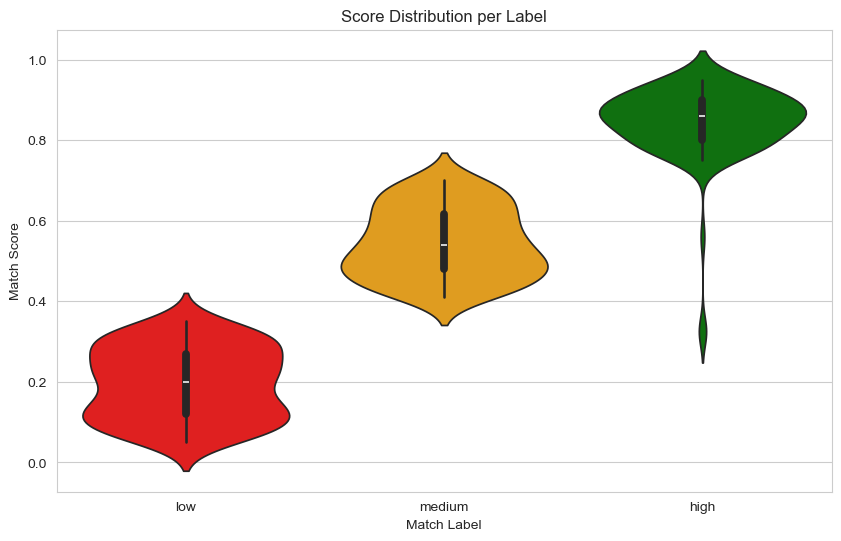

In [126]:
import seaborn as sns

df_plot = df.copy()
df_plot['match_label'] = df_plot['match_label'].str.lower()
df_plot = df_plot[(df_plot['match_score'] >= 0) & (df_plot['match_score'] <= 1)]

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_plot, x='match_label', y='match_score',
               order=['low','medium','high'],
               palette=['red','orange','green'])
plt.title('Score Distribution per Label')
plt.xlabel('Match Label')
plt.ylabel('Match Score')
plt.show()


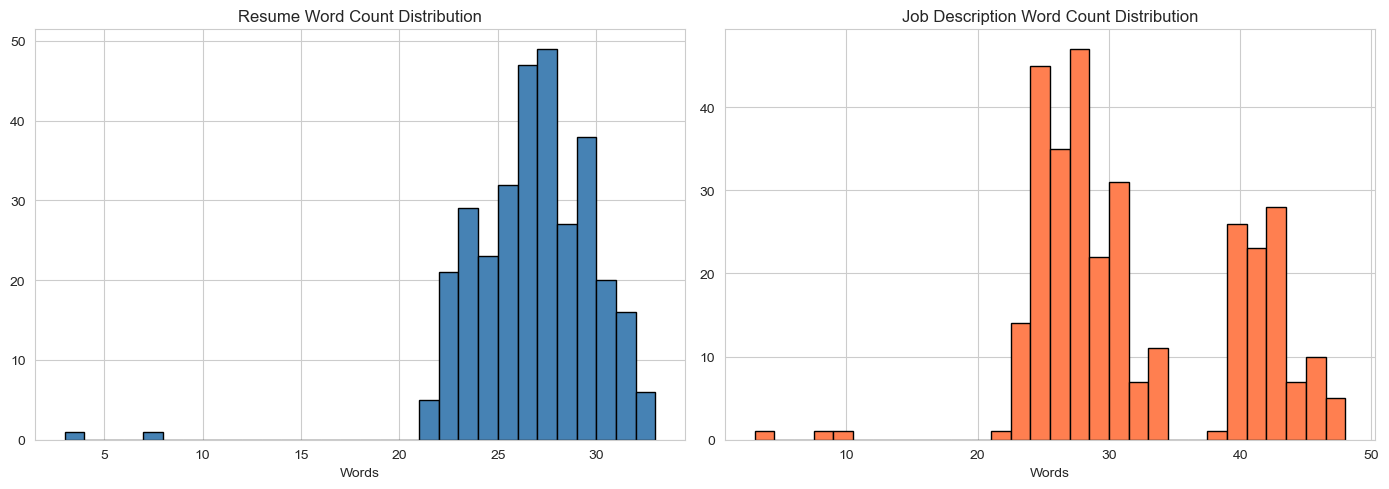

In [127]:
df_plot['resume_len'] = df_plot['resume_text'].str.split().str.len()
df_plot['jd_len']     = df_plot['job_description'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_plot['resume_len'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Resume Word Count Distribution')
axes[0].set_xlabel('Words')

axes[1].hist(df_plot['jd_len'], bins=30, color='coral', edgecolor='black')
axes[1].set_title('Job Description Word Count Distribution')
axes[1].set_xlabel('Words')

plt.tight_layout()
plt.show()

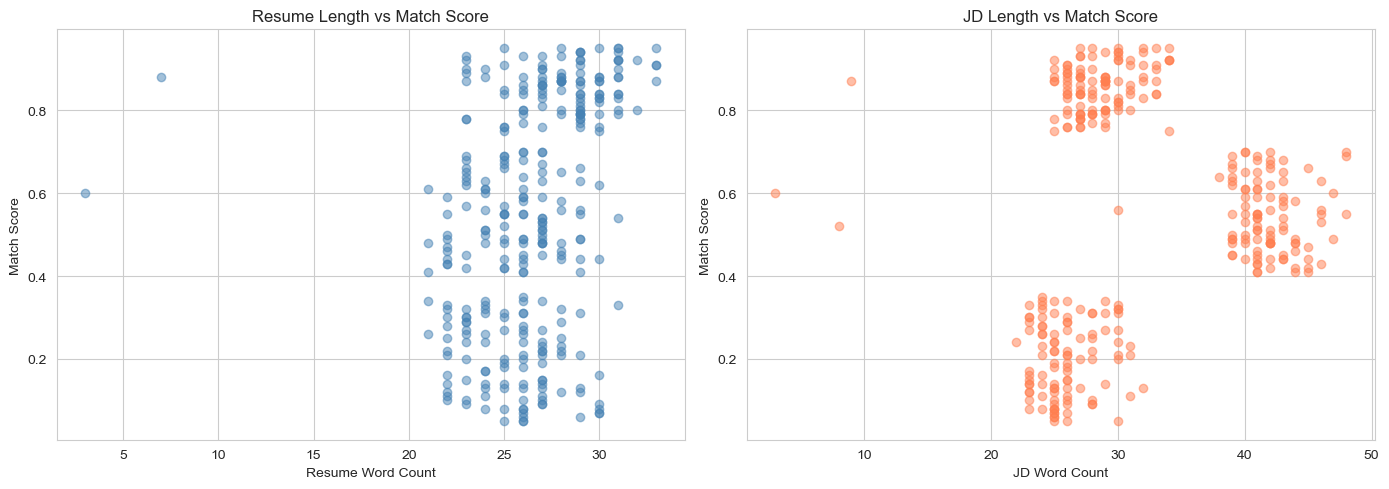

Resume length correlation: 0.304
JD length correlation:     0.138


In [128]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_plot['resume_len'], df_plot['match_score'], alpha=0.5, color='steelblue')
axes[0].set_xlabel('Resume Word Count')
axes[0].set_ylabel('Match Score')
axes[0].set_title('Resume Length vs Match Score')

axes[1].scatter(df_plot['jd_len'], df_plot['match_score'], alpha=0.5, color='coral')
axes[1].set_xlabel('JD Word Count')
axes[1].set_ylabel('Match Score')
axes[1].set_title('JD Length vs Match Score')

plt.tight_layout()
plt.show()

# Actual correlation values
print("Resume length correlation:", df_plot['resume_len'].corr(df_plot['match_score']).round(3))
print("JD length correlation:    ", df_plot['jd_len'].corr(df_plot['match_score']).round(3))


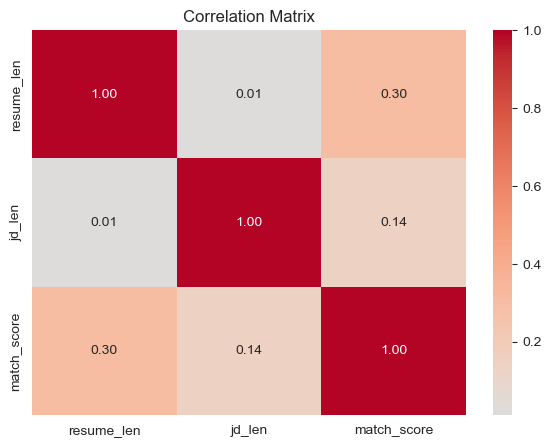

In [129]:
plt.figure(figsize=(7, 5))
corr = df_plot[['resume_len', 'jd_len', 'match_score']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()


In [130]:
pip install wordcloud

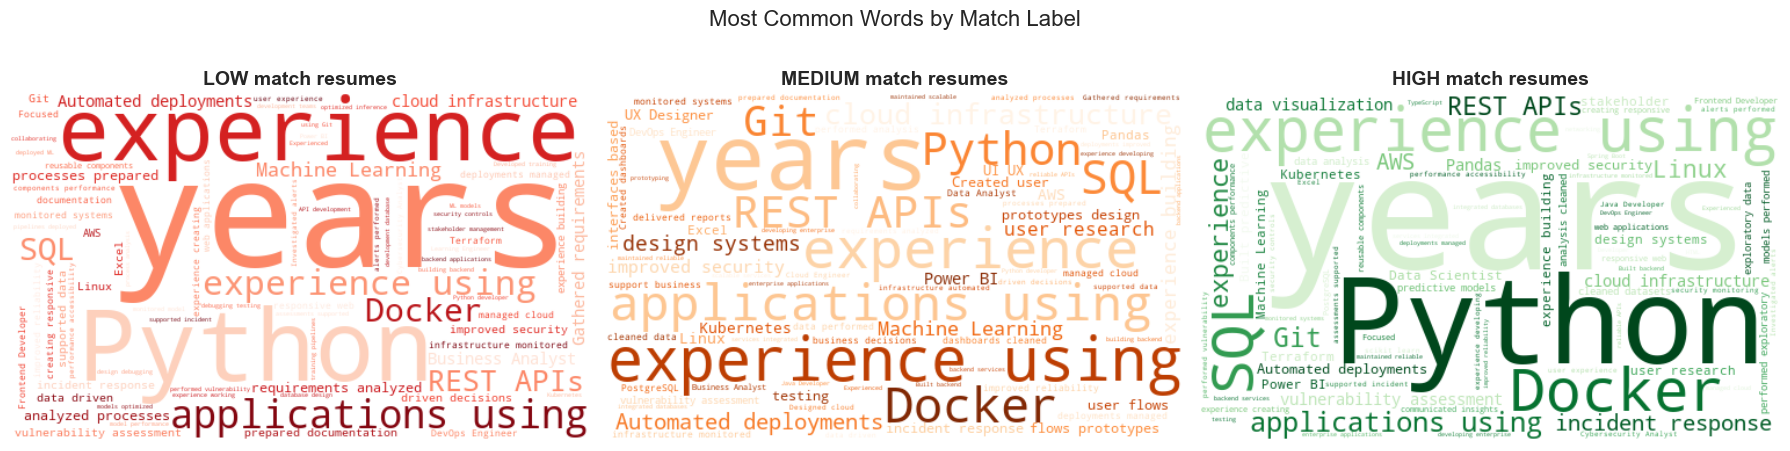

In [131]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels  = ['low', 'medium', 'high']
colors  = ['Reds', 'Oranges', 'Greens']

for ax, label, cmap in zip(axes, labels, colors):
    text = ' '.join(df_plot[df_plot['match_label'] == label]['resume_text'].dropna())
    wc = WordCloud(width=500, height=300, background_color='white',
                   colormap=cmap, max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{label.upper()} match resumes', fontsize=14, fontweight='bold')

plt.suptitle('Most Common Words by Match Label', fontsize=16)
plt.tight_layout()
plt.show()


In [132]:
print("BEFORE CLEANING")
print("=" * 40)
print(f"Total rows:       {len(df)}")
print(f"Null resume_text: {df['resume_text'].isnull().sum()}")
print(f"Null job_desc:    {df['job_description'].isnull().sum()}")
print(f"Duplicates:       {df.duplicated().sum()}")
print(f"Label variants:   {df['match_label'].nunique()}")
print(f"Invalid scores:   {((df['match_score'] < 0) | (df['match_score'] > 1)).sum()}")

df_clean = df.copy()

BEFORE CLEANING
Total rows:       320
Null resume_text: 2
Null job_desc:    1
Duplicates:       7
Label variants:   9
Invalid scores:   3


In [133]:
# Problem: 'high', 'High', 'HIGH' are treated as 3 different categories
print("Before:", df_clean['match_label'].value_counts().to_dict())

df_clean['match_label'] = df_clean['match_label'].str.lower().str.strip()

print("After: ", df_clean['match_label'].value_counts().to_dict())
print(f"\nUnique labels now: {df_clean['match_label'].nunique()} (expected 3)")

Before: {'HIGH': 42, 'Medium': 39, 'high': 38, 'low': 37, 'medium': 36, 'High': 36, 'LOW': 35, 'Low': 29, 'MEDIUM': 27}
After:  {'high': 116, 'medium': 102, 'low': 101}

Unique labels now: 3 (expected 3)


In [134]:
print(f"Before dropping nulls: {len(df_clean)} rows")

df_clean = df_clean.dropna()

print(f"After dropping nulls:  {len(df_clean)} rows")
print(f"Removed: {len(df) - len(df_clean)} rows")

Before dropping nulls: 320 rows
After dropping nulls:  316 rows
Removed: 4 rows


In [135]:
print(f"Before removing duplicates: {len(df_clean)} rows")
print(f"Duplicate pairs found: {df_clean.duplicated(subset=['resume_text','job_description']).sum()}")

df_clean = df_clean.drop_duplicates(subset=['resume_text', 'job_description'], keep='first')

print(f"After removing duplicates:  {len(df_clean)} rows")

Before removing duplicates: 316 rows
Duplicate pairs found: 12
After removing duplicates:  304 rows


In [136]:
# Scores must be in [0.0, 1.0], anything else is a data error
invalid_mask = (df_clean['match_score'] < 0.0) | (df_clean['match_score'] > 1.0)
print(f"Invalid scores found: {invalid_mask.sum()}")
print(df_clean[invalid_mask][['match_label','match_score']])

df_clean = df_clean[~invalid_mask]
print(f"\nRows after removing invalid scores: {len(df_clean)}")

Invalid scores found: 3
    match_label  match_score
6          high        99.00
46         high         1.25
218         low        -0.15

Rows after removing invalid scores: 301


In [137]:

# Expected: low=0.05-0.35, medium=0.40-0.70, high=0.75-0.95

print("Score range per label:")
print(df_clean.groupby('match_label')['match_score'].agg(['min','max','mean']).round(2))


def label_score_mismatch(row):
    score = row['match_score']
    label = row['match_label']
    if label == 'high'   and score < 0.70: return True
    if label == 'medium' and (score < 0.35 or score > 0.75): return True
    if label == 'low'    and score > 0.40: return True
    return False

mismatches = df_clean.apply(label_score_mismatch, axis=1)
print(f"\nLabel-score mismatches: {mismatches.sum()}")
df_clean[mismatches][['match_label','match_score']]

Score range per label:
              min   max  mean
match_label                  
high         0.33  0.95  0.85
low          0.05  0.35  0.20
medium       0.41  0.70  0.54

Label-score mismatches: 2


,match_label,match_score
26,high,0.33
96,high,0.56


In [138]:
df_clean = df_clean.reset_index(drop=True)

print("=" * 45)
print("CLEANING SUMMARY")
print("=" * 45)
print(f"  Original rows:        {len(df)}")
print(f"  Final rows:           {len(df_clean)}")
print(f"  Rows removed:         {len(df) - len(df_clean)}")
print()
print(f"  Nulls remaining:      {df_clean.isnull().sum().sum()}")
print(f"  Duplicates remaining: {df_clean.duplicated().sum()}")
print(f"  Label variants:       {df_clean['match_label'].nunique()}")
print(f"  Score range:          {df_clean['match_score'].min()} – {df_clean['match_score'].max()}")
print()
print("Label distribution after cleaning:")
print(df_clean['match_label'].value_counts())
print("=" * 45)

CLEANING SUMMARY
  Original rows:        320
  Final rows:           301
  Rows removed:         19

  Nulls remaining:      0
  Duplicates remaining: 0
  Label variants:       3
  Score range:          0.05 – 0.95

Label distribution after cleaning:
match_label
medium    101
high      100
low       100
Name: count, dtype: int64


In [139]:

df_clean.to_csv('dataset/cleaned_resumeJD_pairs.csv', index=False)
print(f"Saved: dataset/cleaned_resumeJD_pairs.csv ({len(df_clean)} rows)")

Saved: dataset/cleaned_resumeJD_pairs.csv (301 rows)
